 Fraud Detection


 Fraud detection involves identifying and preventing deceptive activities within financial
transactions or systems. Leveraging advanced analytics and machine learning techniques, fraud
detection systems aim to distinguish between legitimate and fraudulent behavior. Key
components include anomaly detection, pattern recognition, and real-time monitoring.


In [79]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score, precision_score

import warnings
warnings.filterwarnings('ignore')

In [80]:
from google.colab import files
file = files.upload()

Saving creditcard.csv to creditcard (1).csv


In [81]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [82]:
df.shape

(284807, 31)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [84]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [85]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [86]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [87]:
# class distribution
df['Class'].value_counts()
# 0 -> Normal Transaction
# 1 -> Fraud Transaction

,count
Class,
0,284315
1,492


In [88]:
df.isnull().sum()
# no null values

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [89]:
df.duplicated().sum()

np.int64(1081)

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.shape

(283726, 31)

In [93]:
# EDA
# Count of Normal and Fraud Transaction
df["Class"].value_counts()

,count
Class,
0,283253
1,473


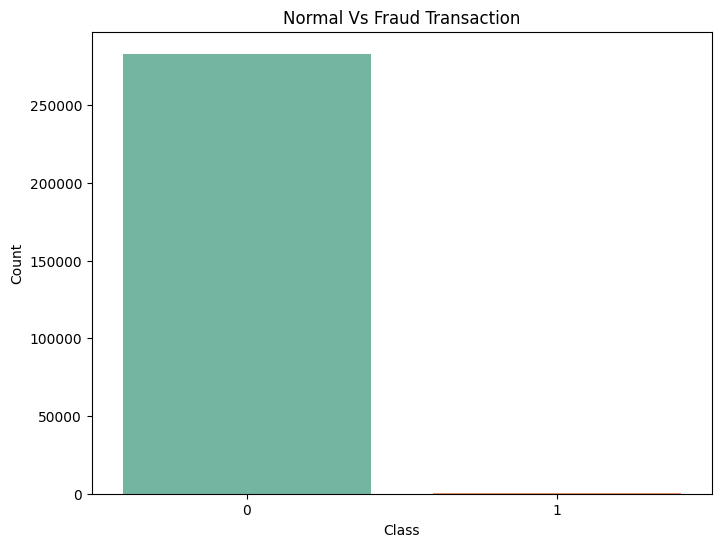

In [94]:
# Count Plot of Transaction class
plt.figure(figsize=(8,6))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Normal Vs Fraud Transaction')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Class Labels:

# 0 → Normal Transaction
# 1 → Fraud Transaction

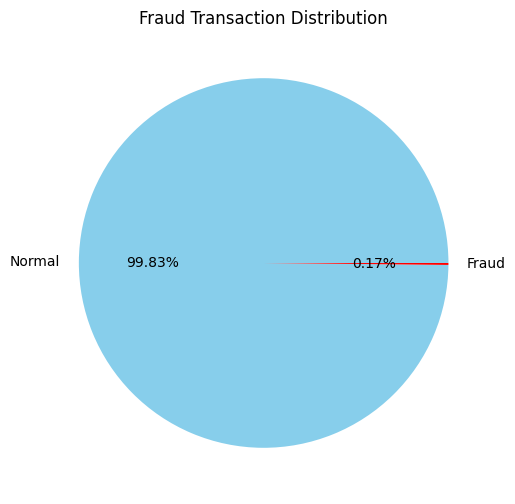

In [95]:
# Pie Chart of Class Distribution
plt.figure(figsize=(6,6))
df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    colors=["skyblue","red"],
    labels=["Normal","Fraud"]
)
plt.title("Fraud Transaction Distribution")
plt.ylabel('')
plt.show()

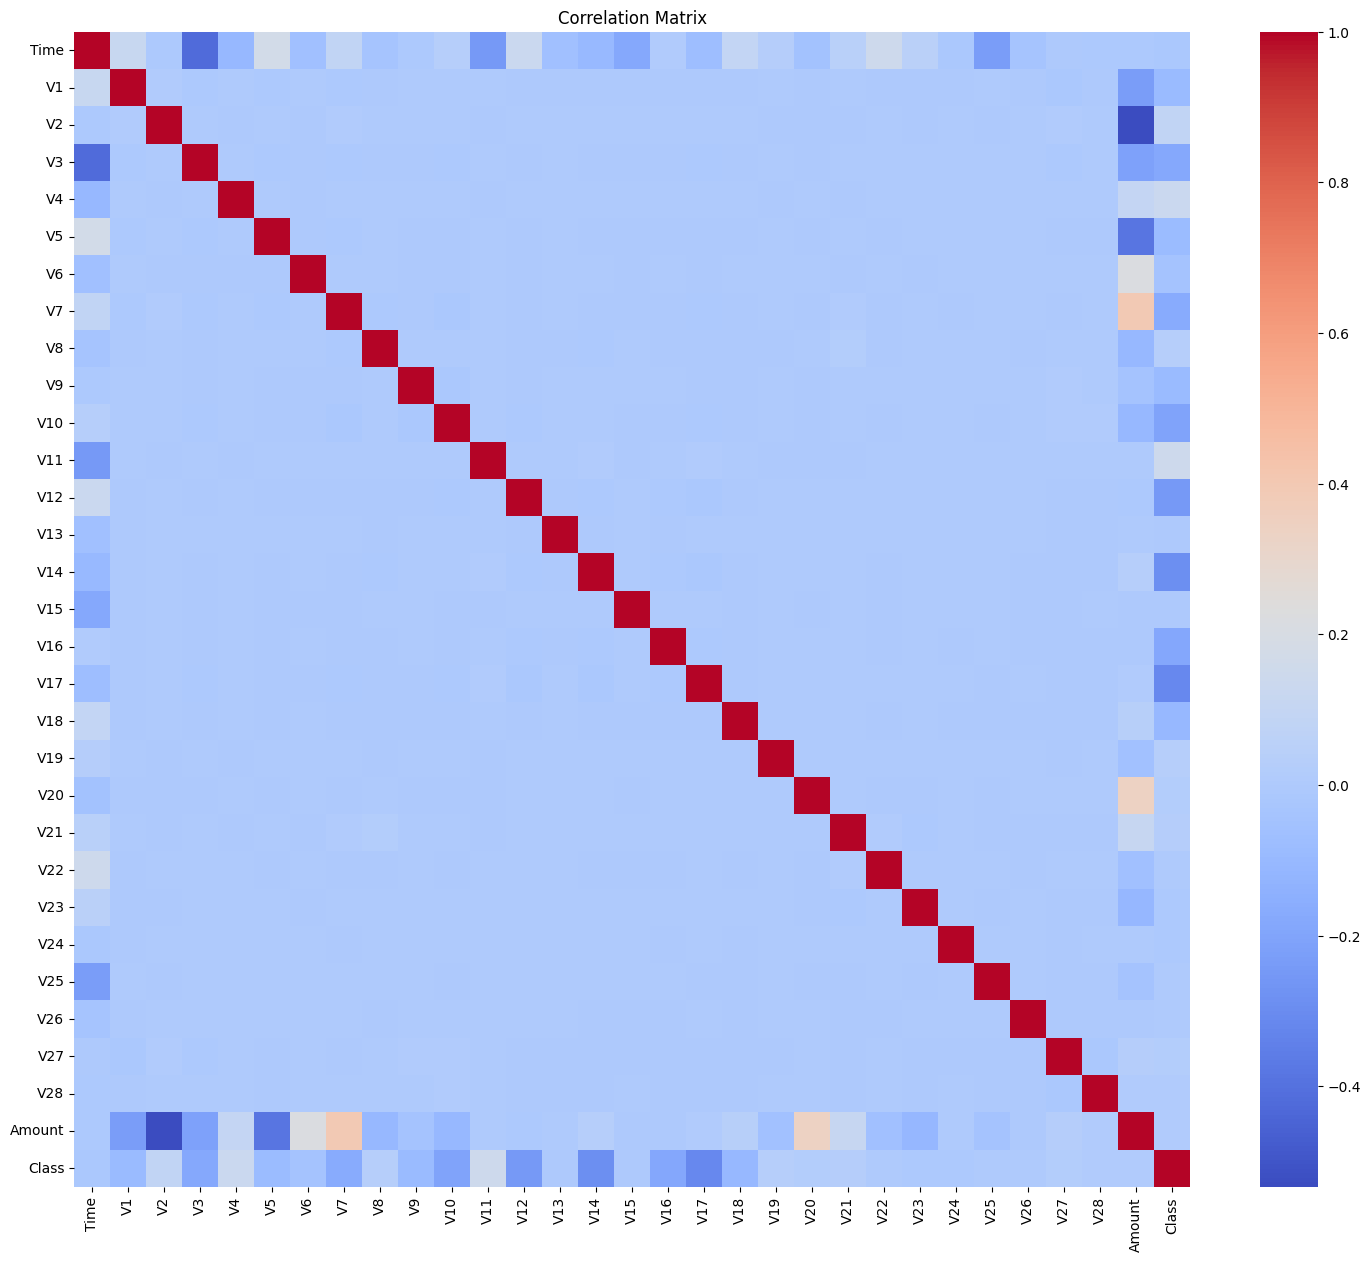

In [96]:
plt.figure(figsize=(18,15))
sns.heatmap(df.corr(), annot=False, cmap ='coolwarm')
plt.title('Correlation Matrix')
plt.show()

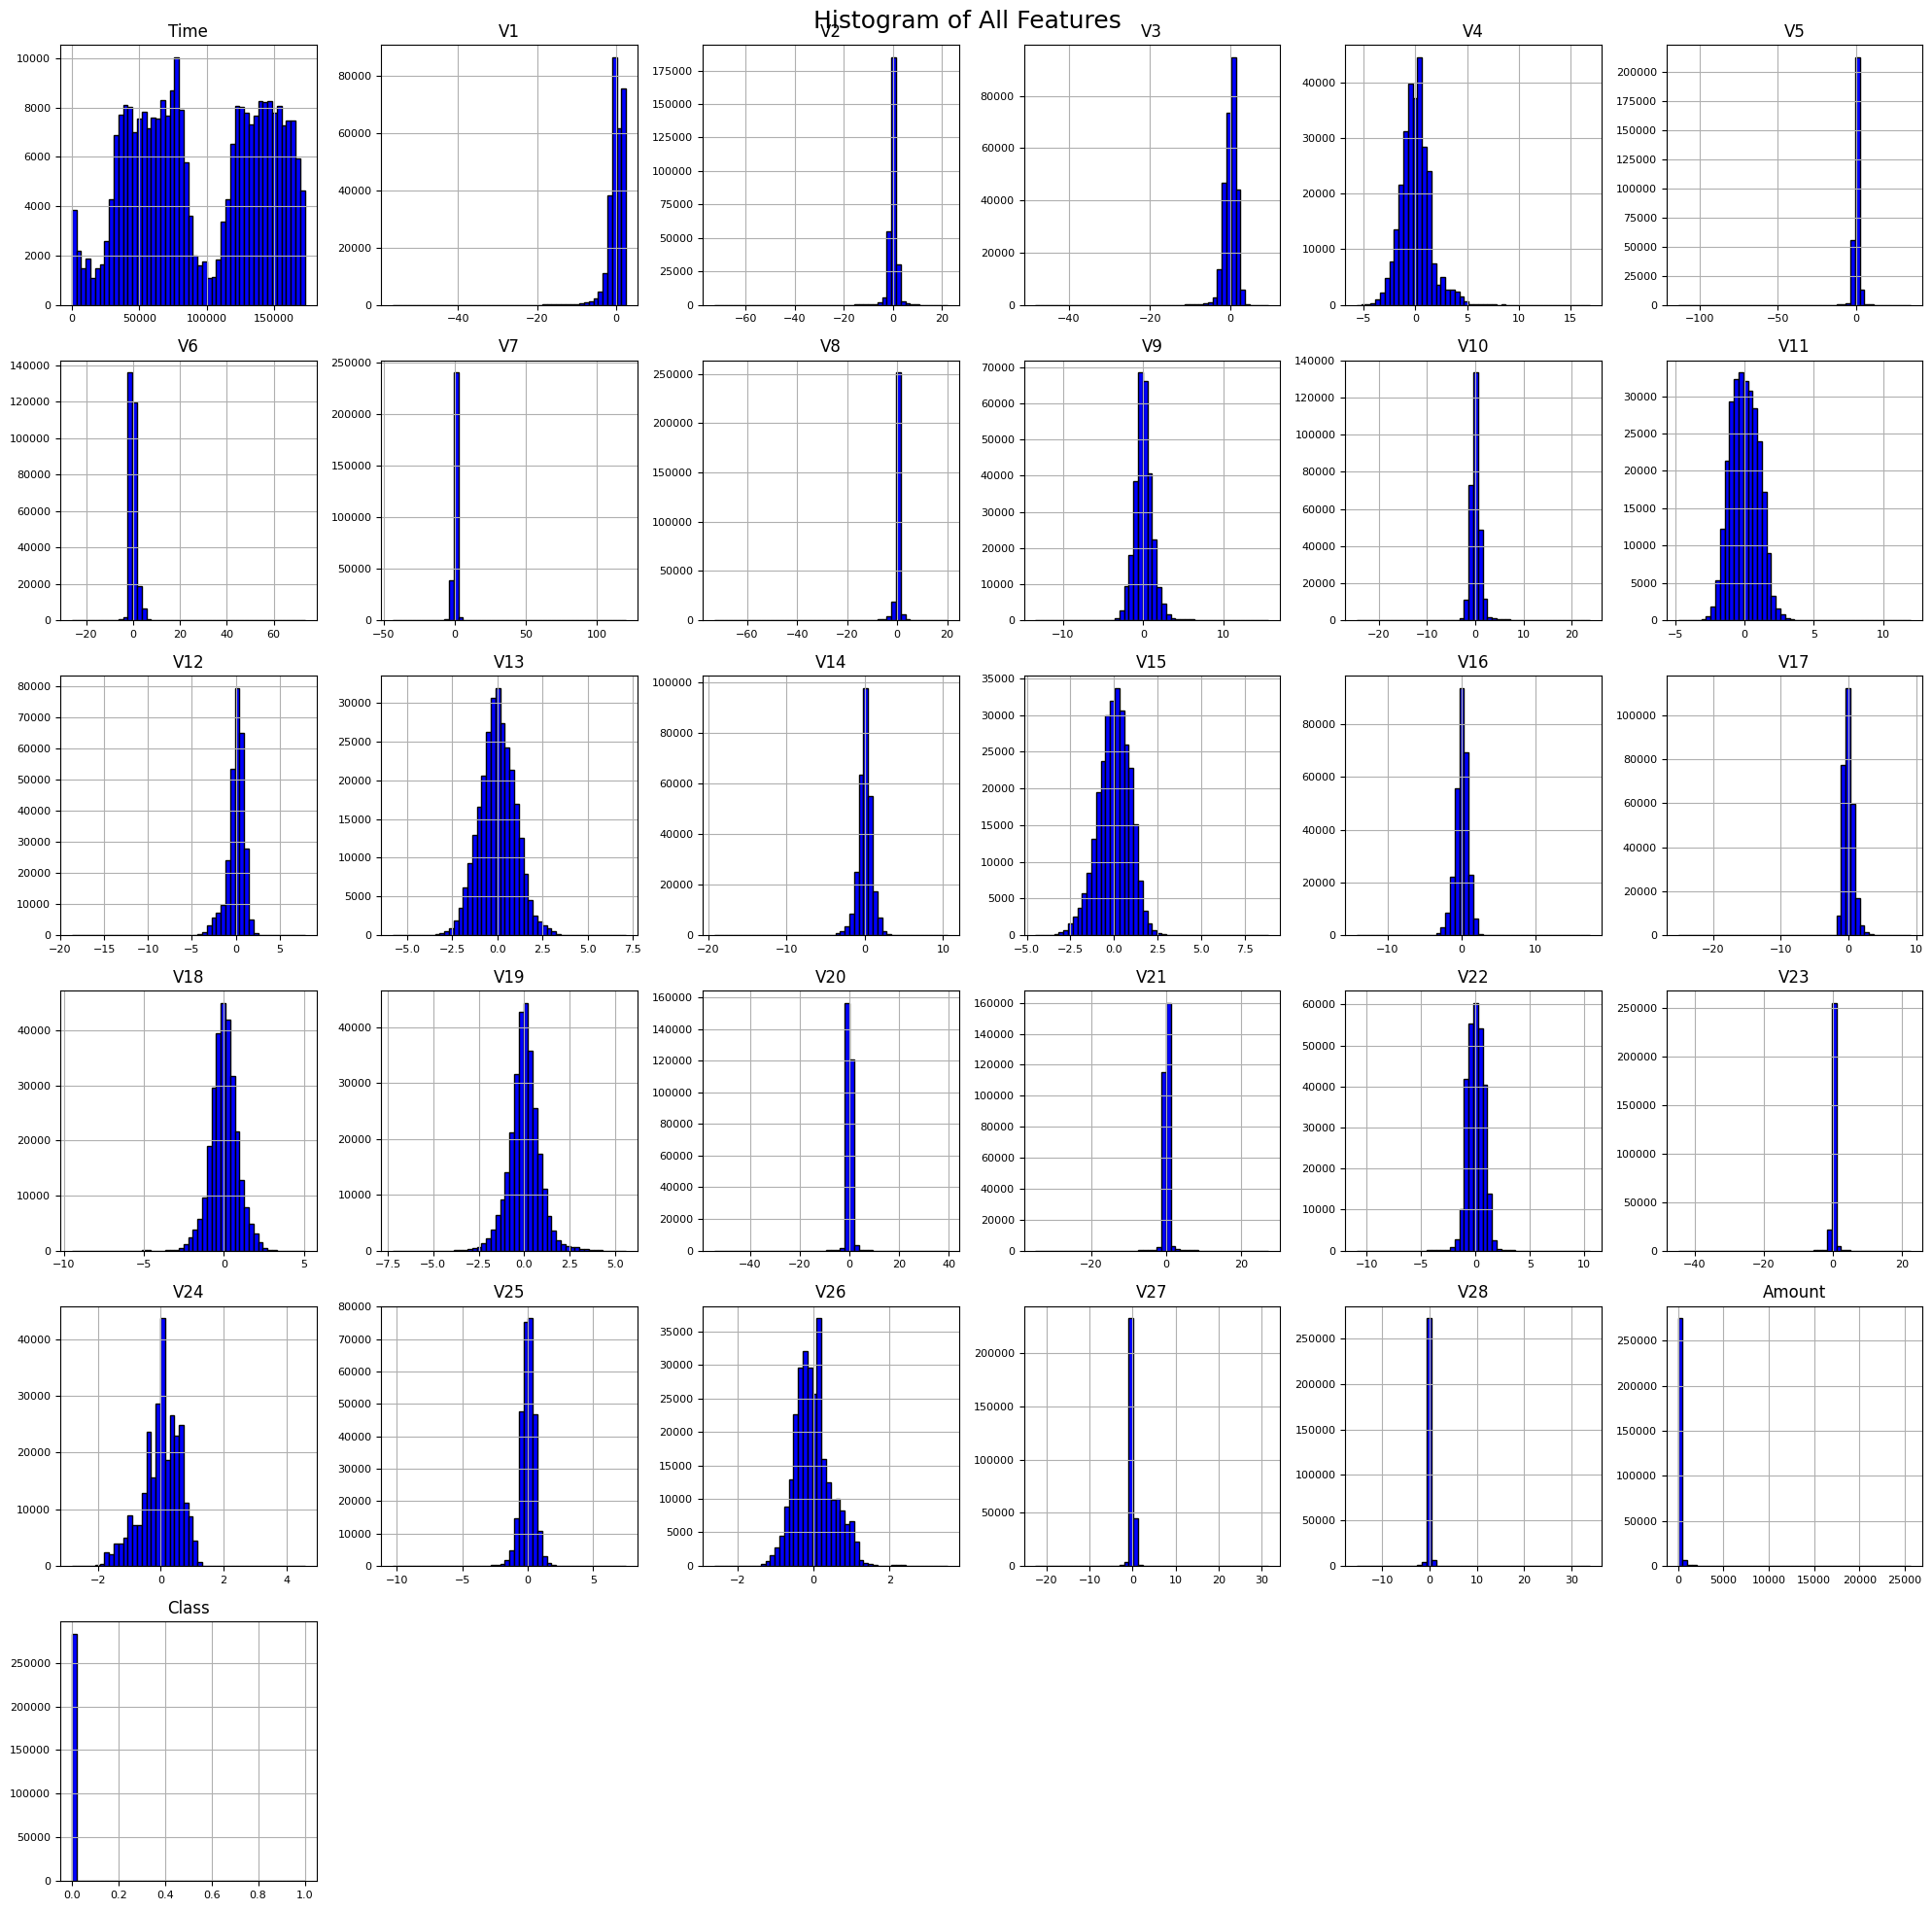

In [97]:
df.hist(
    figsize=(20,20),
    bins=50,
    edgecolor='black',
    color='blue',
    xlabelsize=8,
    ylabelsize=8
)
plt.suptitle('Histogram of All Features', fontsize=18)
plt.tight_layout()
plt.show()

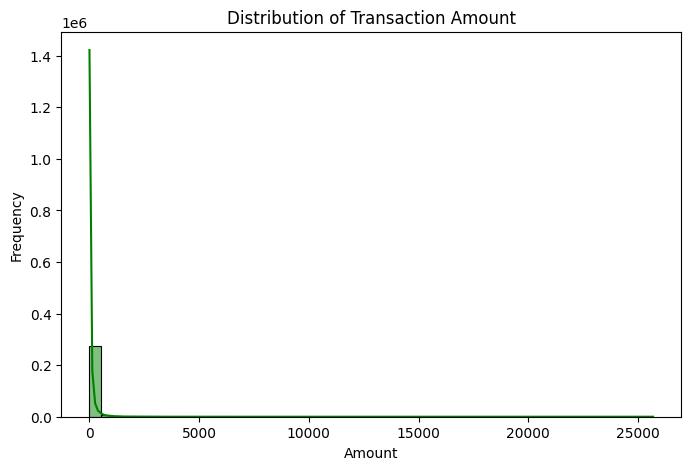

In [98]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Amount'],
    bins=50,
    kde=True,
    color='green',
    edgecolor='black'
)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

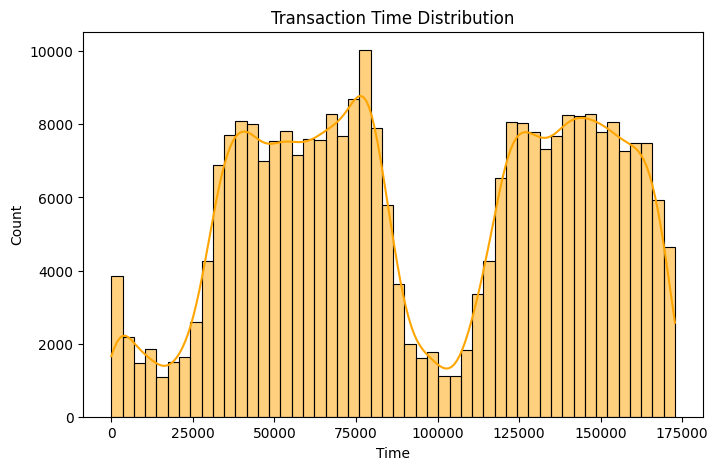

In [99]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Time"],
    bins=50,
    kde=True,
    color="orange"
)
plt.title("Transaction Time Distribution")
plt.show()

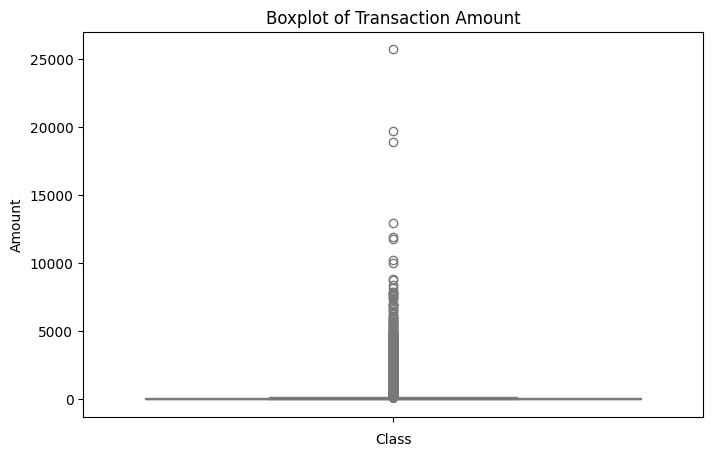

In [100]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df['Amount'],
    color='lightblue'
)
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.show()

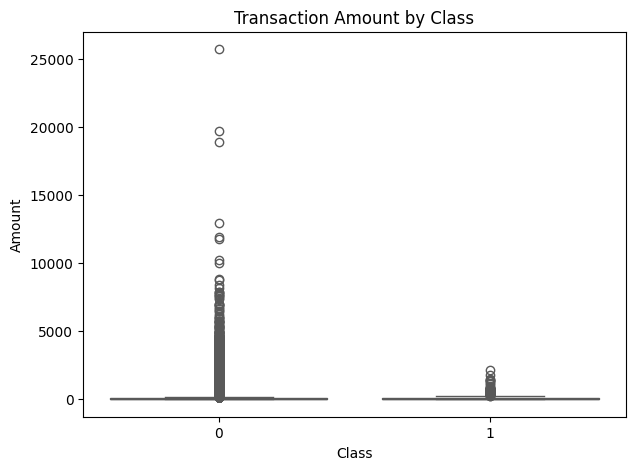

In [101]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="Class",
    y="Amount",
    data=df,
    palette="Set2"
)
plt.title("Transaction Amount by Class")
plt.show()

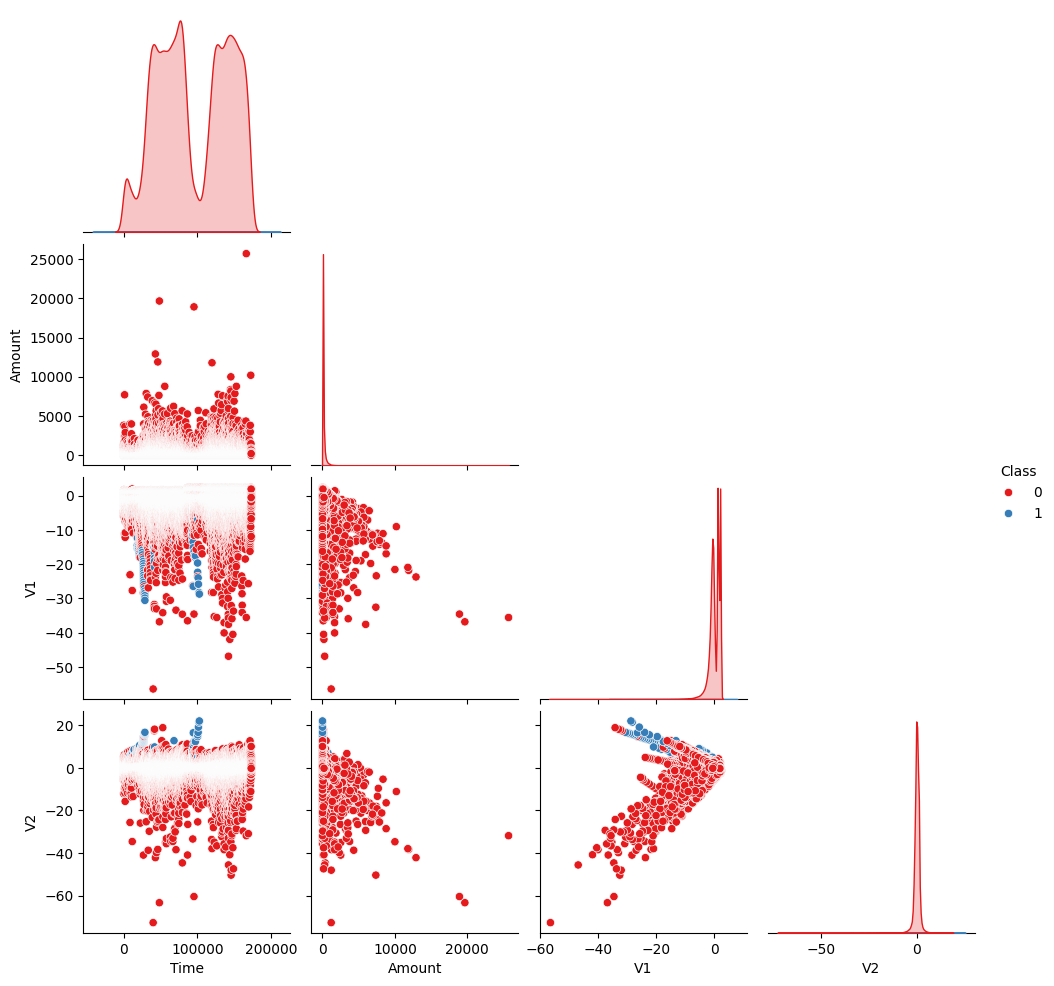

In [102]:
sns.pairplot(
    df[["Time","Amount","V1","V2","Class"]],
    hue="Class",
    palette="Set1",
    corner=True
)
plt.show()

In [103]:
fraud = df["Class"].value_counts()
normal = fraud[0]
fraud_cases = fraud[1]
print("Normal Transactions :", normal)
print("Fraud Transactions :", fraud_cases)
print()
print("Fraud Percentage :",round((fraud_cases/len(df))*100,4),"%")

Normal Transactions : 283253
Fraud Transactions : 473

Fraud Percentage : 0.1667 %


In [104]:
print("Dataset Shape :", df.shape)
print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())
print("Fraud Cases :", fraud_cases)
print("Normal Cases :", normal)

Dataset Shape : (283726, 31)
Missing Values : 0
Duplicate Rows : 0
Fraud Cases : 473
Normal Cases : 283253


In [105]:
# Feature Engineering
# Feature Engineering is the process of preparing the data before training machine learning models.
# For this dataset:

# The features V1 to V28 are already transformed using PCA (Principal Component Analysis).
# We only need to scale the Amount and Time columns because they have different ranges.

scaler = StandardScaler()
df["Scaled_Amount"] = scaler.fit_transform(df[["Amount"]])
df[["Amount", "Scaled_Amount"]].head()

# Why?
# The Amount values vary from very small to very large.
# Scaling helps many machine learning algorithms perform better.

,Amount,Scaled_Amount
0,149.62,0.244200
1,2.69,-0.342584
2,378.66,1.158900
3,123.50,0.139886
4,69.99,-0.073813


In [106]:
df['Scaled_Time'] = scaler.fit_transform(df[['Time']])
df[['Time', 'Scaled_Time']].head()

,Time,Scaled_Time
0,0.0,-1.996823
1,0.0,-1.996823
2,1.0,-1.996802
3,1.0,-1.996802
4,2.0,-1.996781


In [107]:
# Since we have created scaled versions, remove the original columns.
df = df.drop(["Time", "Amount"], axis=1)

In [108]:
# Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (283726, 30)
Shape of y : (283726,)


In [109]:
y.value_counts()
# This means the dataset is highly imbalanced, which is why we'll handle it in the next step using SMOTE.

,count
Class,
0,283253
1,473


In [110]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Scaled_Amount,Scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,-1.996781


In [111]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print()
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)
print()
print("Training Class Distribution")
print(y_train.value_counts())
print()
print("Testing Class Distribution")
print(y_test.value_counts())

Training Features : (226980, 30)
Testing Features  : (56746, 30)

Training Labels : (226980,)
Testing Labels  : (56746,)

Training Class Distribution
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution
Class
0    56651
1       95
Name: count, dtype: int64


Handle Imbalanced Dataset (SMOTE)

The fraud dataset is highly imbalanced.

Example:

Normal → 99.8%
Fraud → 0.2%

If we train directly on this data, the model may simply predict every transaction as Normal and still achieve very high accuracy.

To solve this, we'll use SMOTE (Synthetic Minority Oversampling Technique).

In [113]:
!pip install imbalanced-learn

In [114]:
from imblearn.over_sampling import SMOTE
# Check Class Distribution Before SMOTE
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64


In [115]:
# apply smote
print()
smote = SMOTE(random_state=42)
# Balance the training dataset
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print("After SMOTE")
print(y_train_smote.value_counts())
# Now both classes should have the same number of samples.


After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


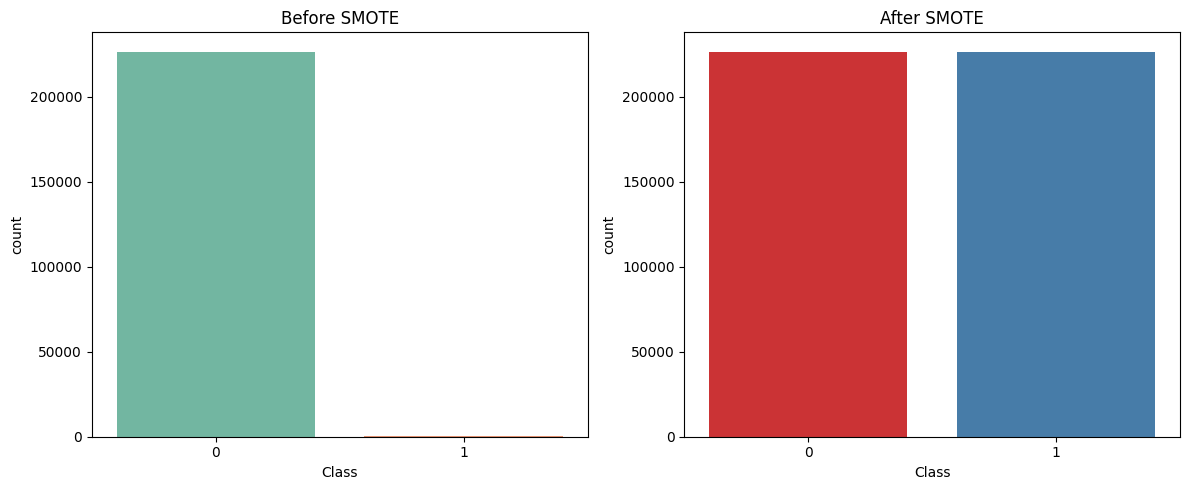

In [116]:
# compare before and after smot
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=ax[0], palette="Set2")
ax[0].set_title("Before SMOTE")

# After SMOTE
sns.countplot(x=y_train_smote, ax=ax[1], palette="Set1")
ax[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

In [117]:
print("Training Features :", X_train.shape)
print("Training Labels :", y_train_smote.shape)

Training Features : (226980, 30)
Training Labels : (453204,)


In [118]:
print("Balanced Dataset")
print(y_train_smote.value_counts(normalize=True)*100)

Balanced Dataset
Class
0    50.0
1    50.0
Name: proportion, dtype: float64


What We Did

Split the dataset into training and testing sets.

Used stratify=y to preserve the class ratio.

Installed and imported SMOTE.

Applied SMOTE only to the training data.

Balanced the training dataset.

Compared class distributions before and after SMOTE.

Important: We apply SMOTE only to the training set. The test set should remain unchanged so that evaluation reflects real-world performance.

In [119]:
# Train
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

In [120]:
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy :",accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy : 0.9737250202657456


In [121]:
# Model 2: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [122]:
dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy :",accuracy_score(y_test, dt_pred))

Decision Tree Accuracy : 0.9977619567899059


In [73]:
# Model 3: Random Forest Classifier
rf_mrf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mrf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy :",accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.9994889507630493


In [74]:
print("Logistic Regression :", accuracy_score(y_test, lr_pred))
print("Decision Tree       :", accuracy_score(y_test, dt_pred))
print("Random Forest       :", accuracy_score(y_test, rf_pred))

Logistic Regression : 0.9737250202657456
Decision Tree       : 0.9977619567899059
Random Forest       : 0.9994889507630493


In [75]:
lr_pred[:10]
dt_pred[:10]
rf_pred[:10]
print("Logistic Regression Model Trained Successfully")
print("Decision Tree Model Trained Successfully")
print("Random Forest Model Trained Successfully")

Logistic Regression Model Trained Successfully
Decision Tree Model Trained Successfully
Random Forest Model Trained Successfully


In [76]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



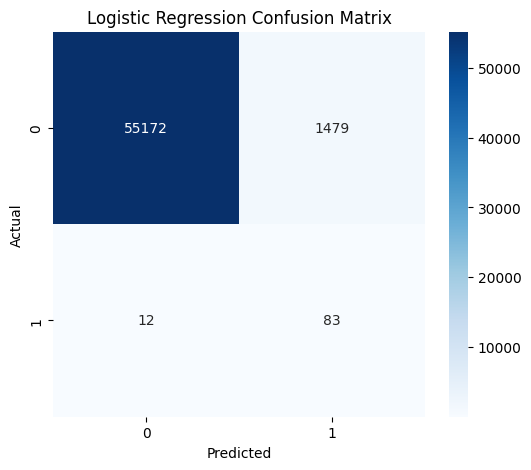

In [77]:
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [125]:
# Decision Tree Evaluation
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision :", precision_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC Score :", roc_auc_score(y_test, dt_pred))

Accuracy : 0.9977619567899059
Precision : 0.4036144578313253
F1 Score : 0.5134099616858238
ROC-AUC Score : 0.8517578079636258


In [ ]:
print(classification_report(y_test, dt_pred))

In [ ]:
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Random Forest Evaluation
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC Score :", roc_auc_score(y_test, rf_pred))

In [ ]:
print(classification_report(y_test, rf_pred))

In [ ]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ROC Curve Comparison
# This graph compares all three models.
lr_prob = lr_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
# Calculate ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred)
    ]

})

comparison

In [ ]:
comparison = comparison.round(4)
comparison

In [127]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison,
    palette="viridis"
)
plt.title("Model Accuracy Comparison")
plt.ylim(0.90,1)
plt.show()

NameError: name 'comparison' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Precision",
    data=comparison,
    palette="magma"
)
plt.title("Model Precision Comparison")
plt.ylim(0,1)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Recall",
    data=comparison,
    palette="Set2"
)
plt.title("Model Recall Comparison")
plt.ylim(0,1)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="F1 Score",
    data=comparison,
    palette="coolwarm"
)
plt.title("Model F1 Score Comparison")
plt.ylim(0,1)
plt.show()

In [132]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
importance.head()

,Feature,Importance
0,V1,0.009204
1,V2,0.025568
2,V3,0.060606
3,V4,0.088475
4,V5,0.009705


In [133]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
13,V14,0.227987
9,V10,0.113291
16,V17,0.104117
3,V4,0.088475
11,V12,0.078795
10,V11,0.071133
2,V3,0.060606
15,V16,0.046264
1,V2,0.025568
6,V7,0.024112


In [134]:
top15 = importance.head(15)
top15

,Feature,Importance
13,V14,0.227987
9,V10,0.113291
16,V17,0.104117
3,V4,0.088475
11,V12,0.078795
10,V11,0.071133
2,V3,0.060606
15,V16,0.046264
1,V2,0.025568
6,V7,0.024112


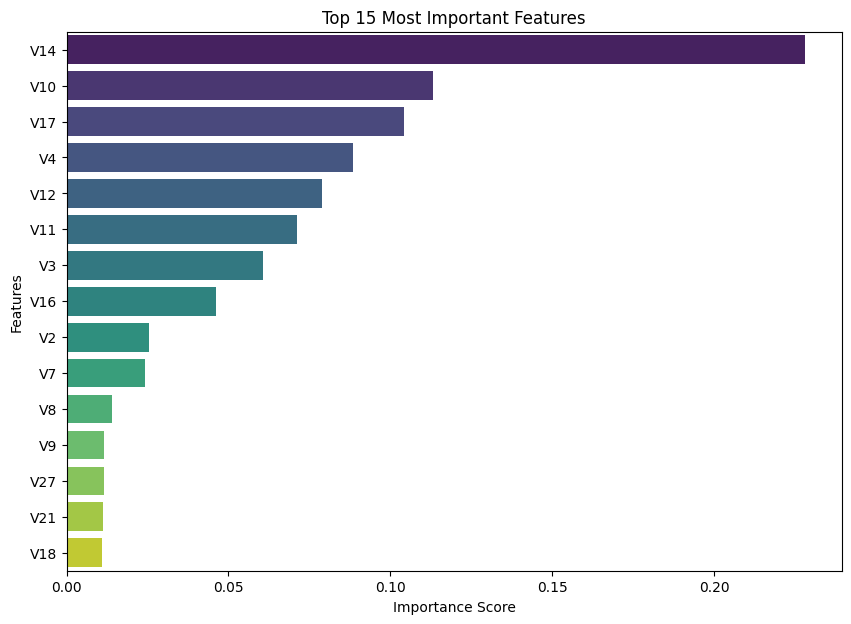

In [135]:
plt.figure(figsize=(10,7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top15,
    palette="viridis"
)
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [136]:
importance

,Feature,Importance
13,V14,0.227987
9,V10,0.113291
16,V17,0.104117
3,V4,0.088475
11,V12,0.078795
10,V11,0.071133
2,V3,0.060606
15,V16,0.046264
1,V2,0.025568
6,V7,0.024112


In [137]:
sample = X.iloc[[0]]
sample

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Scaled_Amount,Scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.5516,-0.617801,-0.99139,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.2442,-1.996823


In [138]:
prediction = rf_model.predict(sample)
print(prediction)

[0]


In [139]:
if prediction[0] == 0:
    print("Normal Transaction")
else:
    print("Fraud Transaction")

Normal Transaction


In [140]:
sample = X.iloc[[1000]]
prediction = rf_model.predict(sample)
if prediction[0] == 0:
    print("Normal Transaction")
else:
    print("Fraud Transaction")

Normal Transaction


In [141]:
samples = X.iloc[0:5]
predictions = rf_model.predict(samples)
print(predictions)

[0 0 0 0 0]


In [142]:
results = pd.DataFrame({
    "Actual": y.iloc[0:5].values,
    "Predicted": predictions
})
results

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [143]:
import joblib
joblib.dump(rf_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")
loaded_model = joblib.load("fraud_detection_model.pkl")
prediction = loaded_model.predict(sample)
print(prediction)

[0]


Conclusion

In this project, a Credit Card Fraud Detection system was developed using Machine Learning techniques. The dataset was explored through Exploratory Data Analysis (EDA), where missing values, duplicate records, and class distribution were analyzed. Since the dataset was highly imbalanced, SMOTE was applied to balance the training data before model training.

Three machine learning algorithms—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Classification Report, and Confusion Matrix.

Among all the models, Random Forest achieved the best overall performance, making it the most suitable model for detecting fraudulent transactions. Feature Importance analysis highlighted the variables that contributed the most to fraud detection. Finally, the trained model was used to predict whether a transaction was fraudulent or legitimate and was saved for future use.

This project demonstrates how machine learning can be effectively applied to detect fraudulent financial transactions and assist financial institutions in preventing fraud.